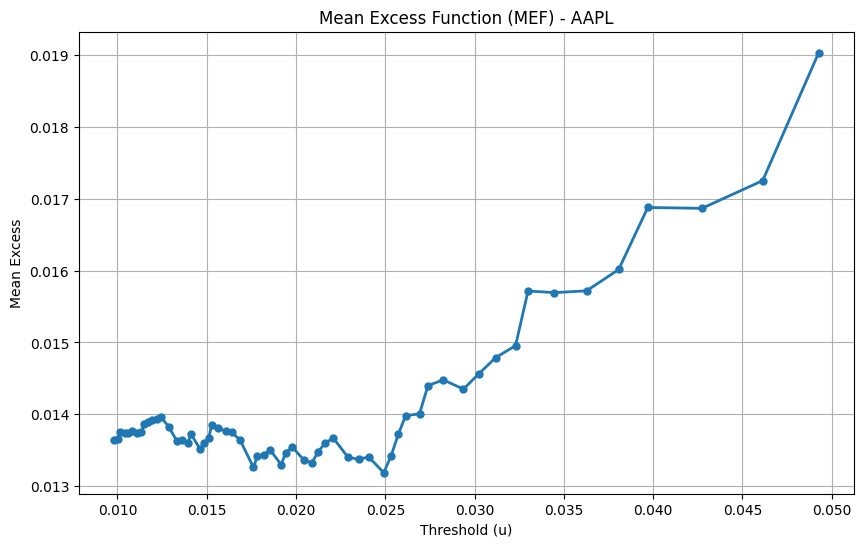

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# Load Data
# ==========================================================

df = pd.read_csv(r"C:\A-CMSI research\Data\features.csv")

# ==========================================================
# Convert Returns to Losses
# ==========================================================

losses = -df["aapl_ret"].dropna()

# ==========================================================
# Candidate Thresholds
# 80th to 99th Percentile
# ==========================================================

thresholds = np.quantile(
    losses,
    np.linspace(0.80, 0.99, 60)
)

mean_excess = []

for u in thresholds:

    exceedances = losses[losses > u] - u

    if len(exceedances) > 0:
        mean_excess.append(exceedances.mean())
    else:
        mean_excess.append(np.nan)

# ==========================================================
# Plot Mean Excess Function
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    thresholds,
    mean_excess,
    marker='o',
    linewidth=2,
    markersize=5
)

plt.xlabel("Threshold (u)")
plt.ylabel("Mean Excess")
plt.title("Mean Excess Function (MEF) - AAPL")

plt.grid(True)

plt.show()

In [2]:
mef_table = pd.DataFrame({
    "Threshold": thresholds,
    "MeanExcess": mean_excess
})

print(mef_table.head(10))

   Threshold  MeanExcess
0   0.009812    0.013637
1   0.010018    0.013655
2   0.010144    0.013758
3   0.010398    0.013737
4   0.010606    0.013740
5   0.010813    0.013774
6   0.011092    0.013741
7   0.011332    0.013750
8   0.011478    0.013860
9   0.011703    0.013896


In [3]:
mef_table

,Threshold,MeanExcess
0,0.009812,0.013637
1,0.010018,0.013655
2,0.010144,0.013758
3,0.010398,0.013737
4,0.010606,0.013740
5,0.010813,0.013774
6,0.011092,0.013741
7,0.011332,0.013750
8,0.011478,0.013860
9,0.011703,0.013896
